# Logistic Regression

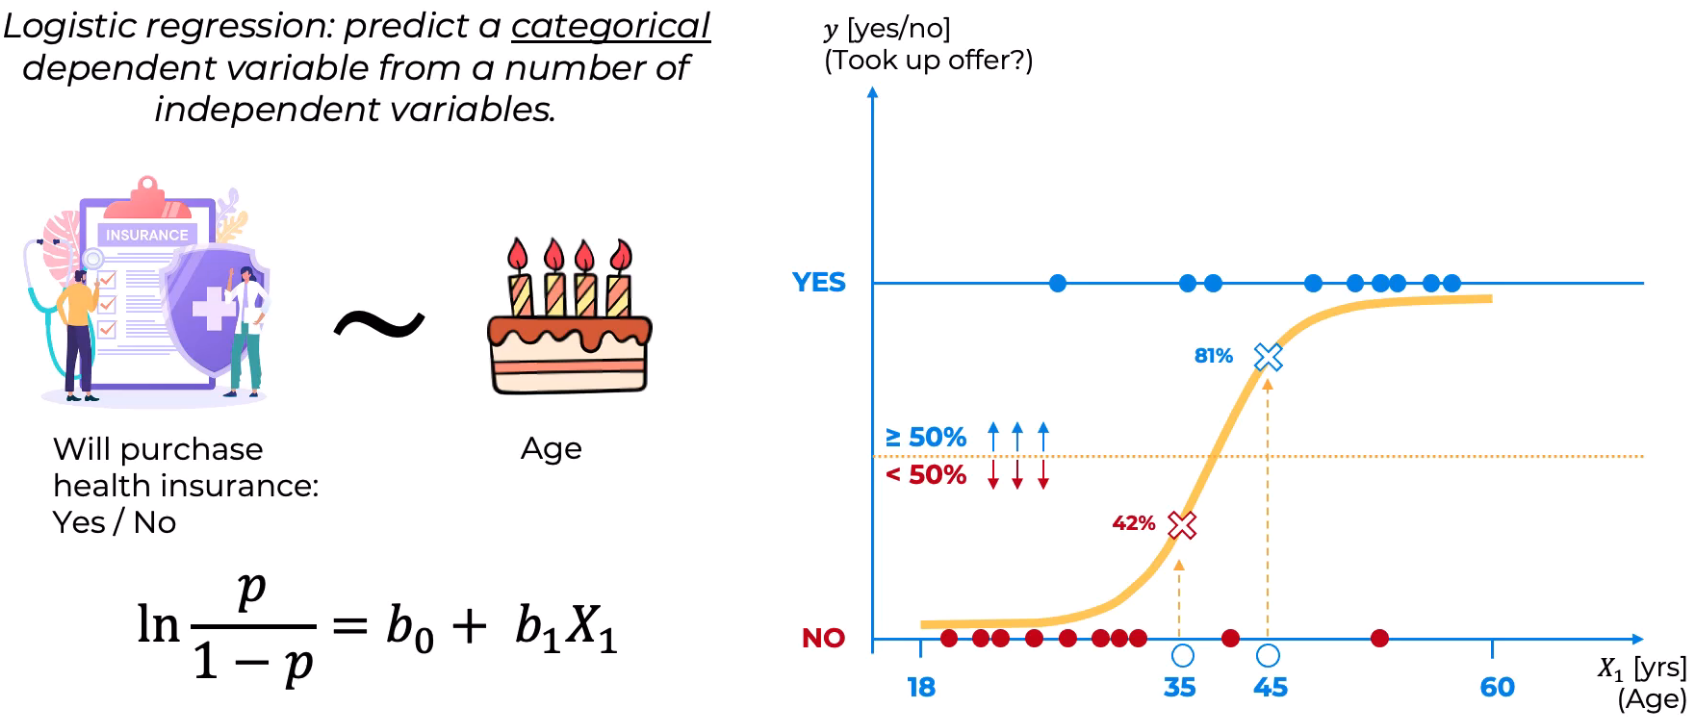

## How to find the best curve?


 ### Likelihood of curve

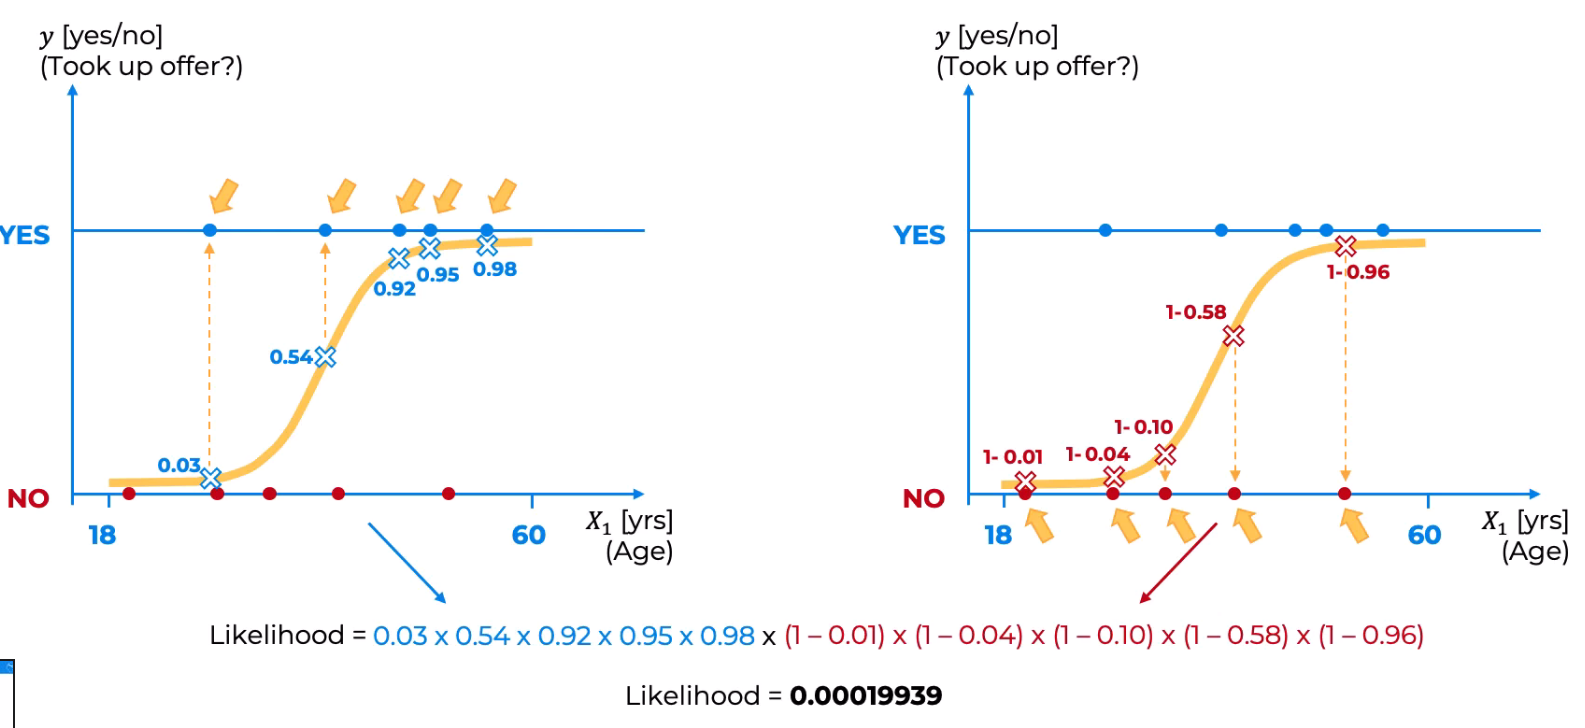

### Maximum likelihood

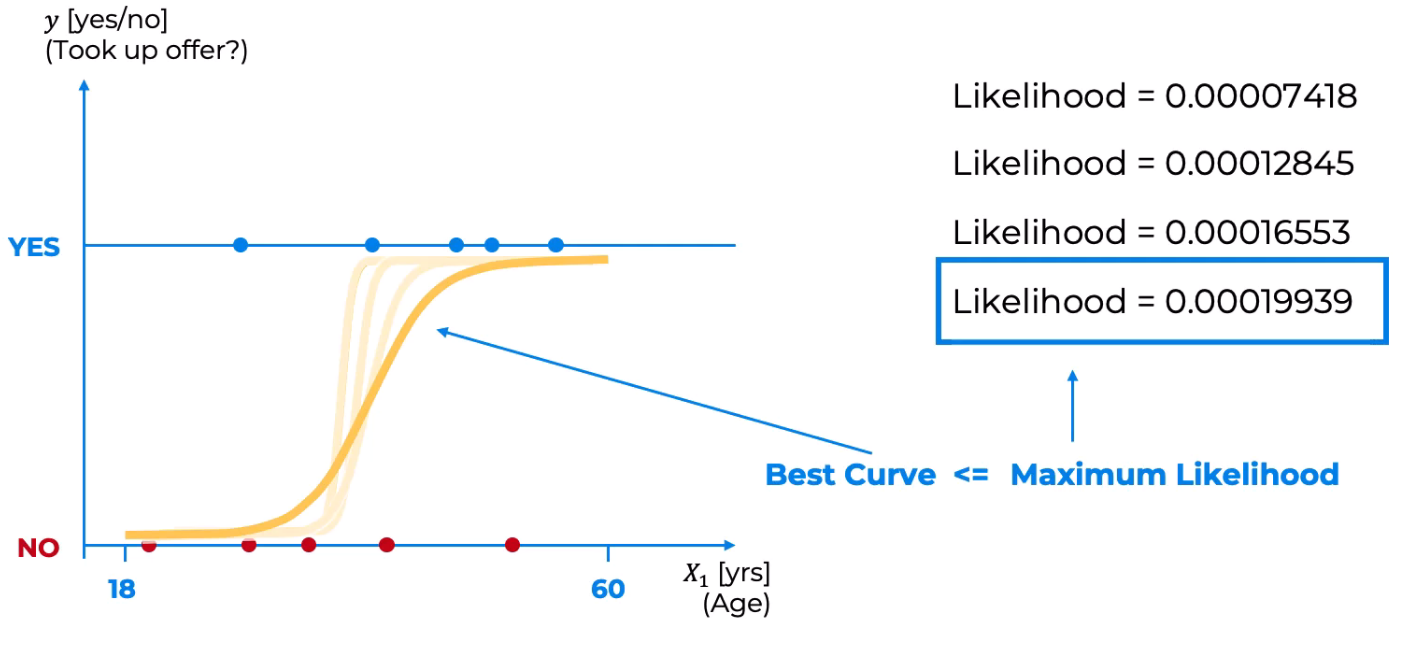

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [ ]:
!wget -O 'Social_Network_Ads.csv' 'https://drive.google.com/uc?export=download&id=1UlewAol4D-sbWa028JczybYYx25Widtw'

dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

--2025-10-20 13:53:48--  https://drive.google.com/uc?export=download&id=1UlewAol4D-sbWa028JczybYYx25Widtw
Resolving drive.google.com (drive.google.com)... 142.251.183.102, 142.251.183.138, 142.251.183.139, ...
Connecting to drive.google.com (drive.google.com)|142.251.183.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1UlewAol4D-sbWa028JczybYYx25Widtw&export=download [following]
--2025-10-20 13:53:48--  https://drive.usercontent.google.com/download?id=1UlewAol4D-sbWa028JczybYYx25Widtw&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.181.132, 2607:f8b0:4001:c09::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.181.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4903 (4.8K) [application/octet-stream]
Saving to: ‘Social_Network_Ads.csv’

Social_Network_Ads. 100%[===================>]   4.79K 

In [ ]:
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


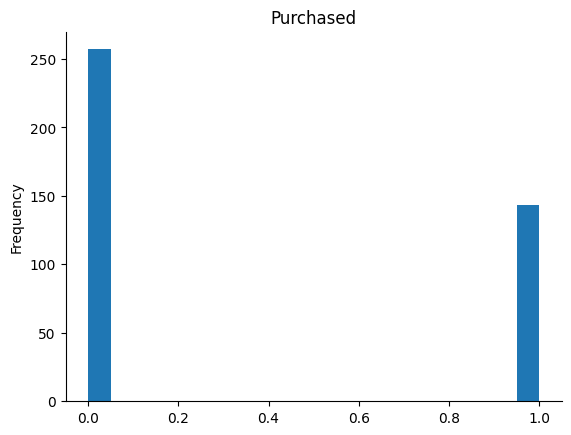

In [ ]:
from matplotlib import pyplot as plt
dataset['Purchased'].plot(kind='hist', bins=20, title='Purchased')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
print(X_train[:5])

[[    28  32000]
 [    40 142000]
 [    35  27000]
 [    49  28000]
 [    50  44000]]


## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

# sc.fit()
# sc.transform()

X_test = sc.transform(X_test)

# mean and std are known at this point

In [ ]:
print(X_test[:5])

[[ 0.23155699  0.23138502]
 [-0.43342719 -0.77346655]
 [-0.62342268  0.54719551]
 [-0.24343171 -0.28539579]
 [ 0.7065457  -1.37637749]]


In [ ]:
X_test[:5]

array([[ 0.23155699,  0.23138502],
       [-0.43342719, -0.77346655],
       [-0.62342268,  0.54719551],
       [-0.24343171, -0.28539579],
       [ 0.7065457 , -1.37637749]])

In [ ]:
y_train[:5]

array([0, 1, 0, 1, 0])

## Training the Logistic Regression model on the Training set

In [ ]:
from sklearn.linear_model import LogisticRegression
LRclassifier = LogisticRegression()
LRclassifier.fit(X_train, y_train)

LogisticRegression()

## Predicting a new result

In [ ]:
age = 30
salary = 87000

ex_scaled = sc.transform( [[age, salary ]] )
ex_scaled

LRclassifier.predict( ex_scaled )

array([0])

In [ ]:
ex_scaled

array([[-0.71842042,  0.48977542]])

In [ ]:
LRclassifier.classes_

array([0, 1])

## Predicting the Test set results

In [ ]:
y_pred = LRclassifier.predict(X_test)

## Making the Classification report

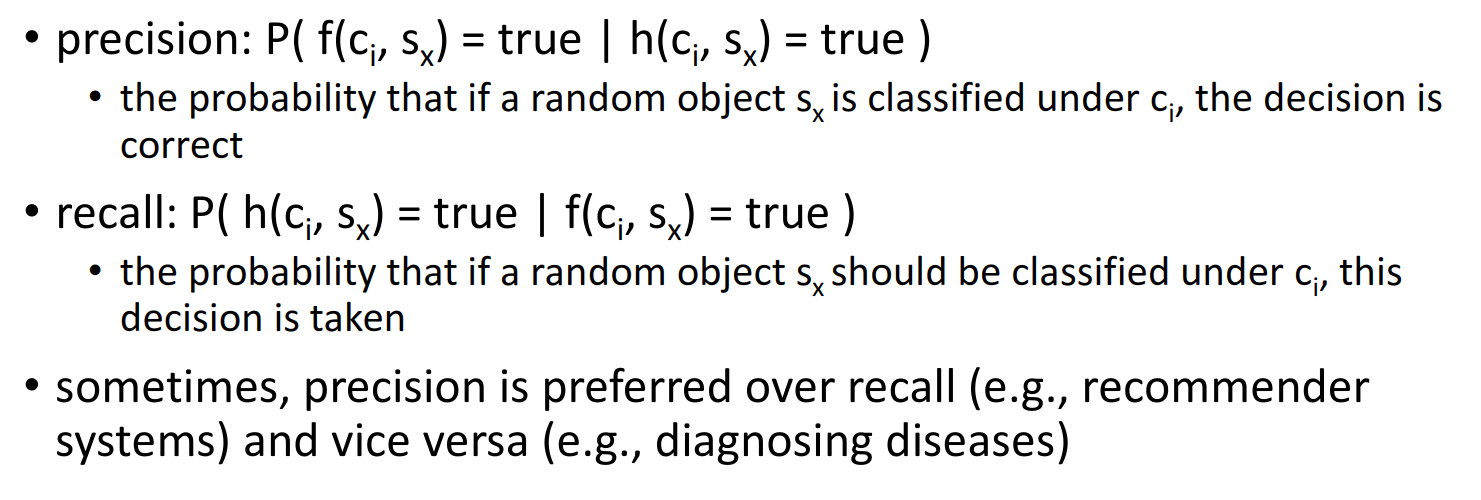

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1])

In [ ]:
y_test

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        55
           1       0.83      0.76      0.79        25

    accuracy                           0.88        80
   macro avg       0.86      0.84      0.85        80
weighted avg       0.87      0.88      0.87        80



## Visualising the Training set results

/tmp/ipython-input-1297592140.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


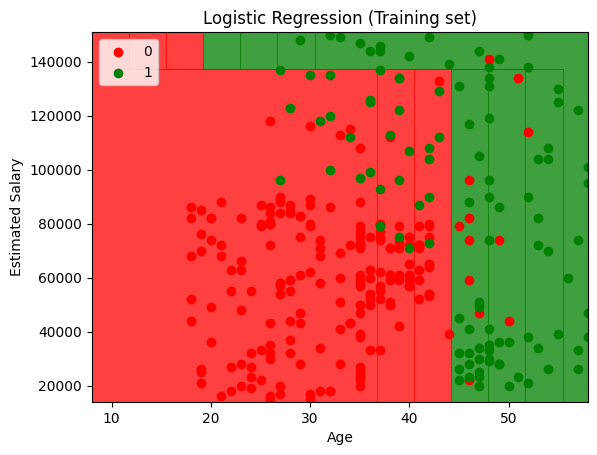

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 25))
X_test_scaled = sc.transform(np.array([X1.ravel(), X2.ravel()]).T)
plt.contourf(X1, X2, LRclassifier.predict(X_test_scaled).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## K-fold cross validation
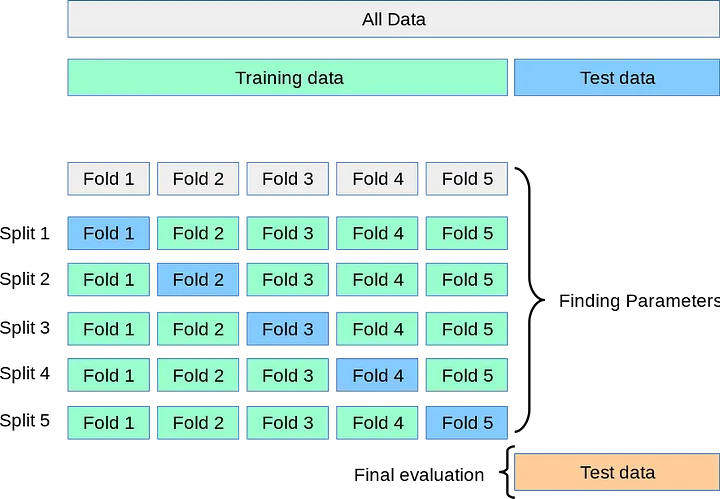

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

LRclassifier = LogisticRegression(random_state = 0)

kf = KFold(shuffle=True, n_splits=5)
scores = cross_val_score(LRclassifier, X, y, cv=kf)

print(scores)
print(np.mean(scores))

[0.8625 0.85   0.7625 0.9125 0.8125]
0.8399999999999999


# Decision tree classification

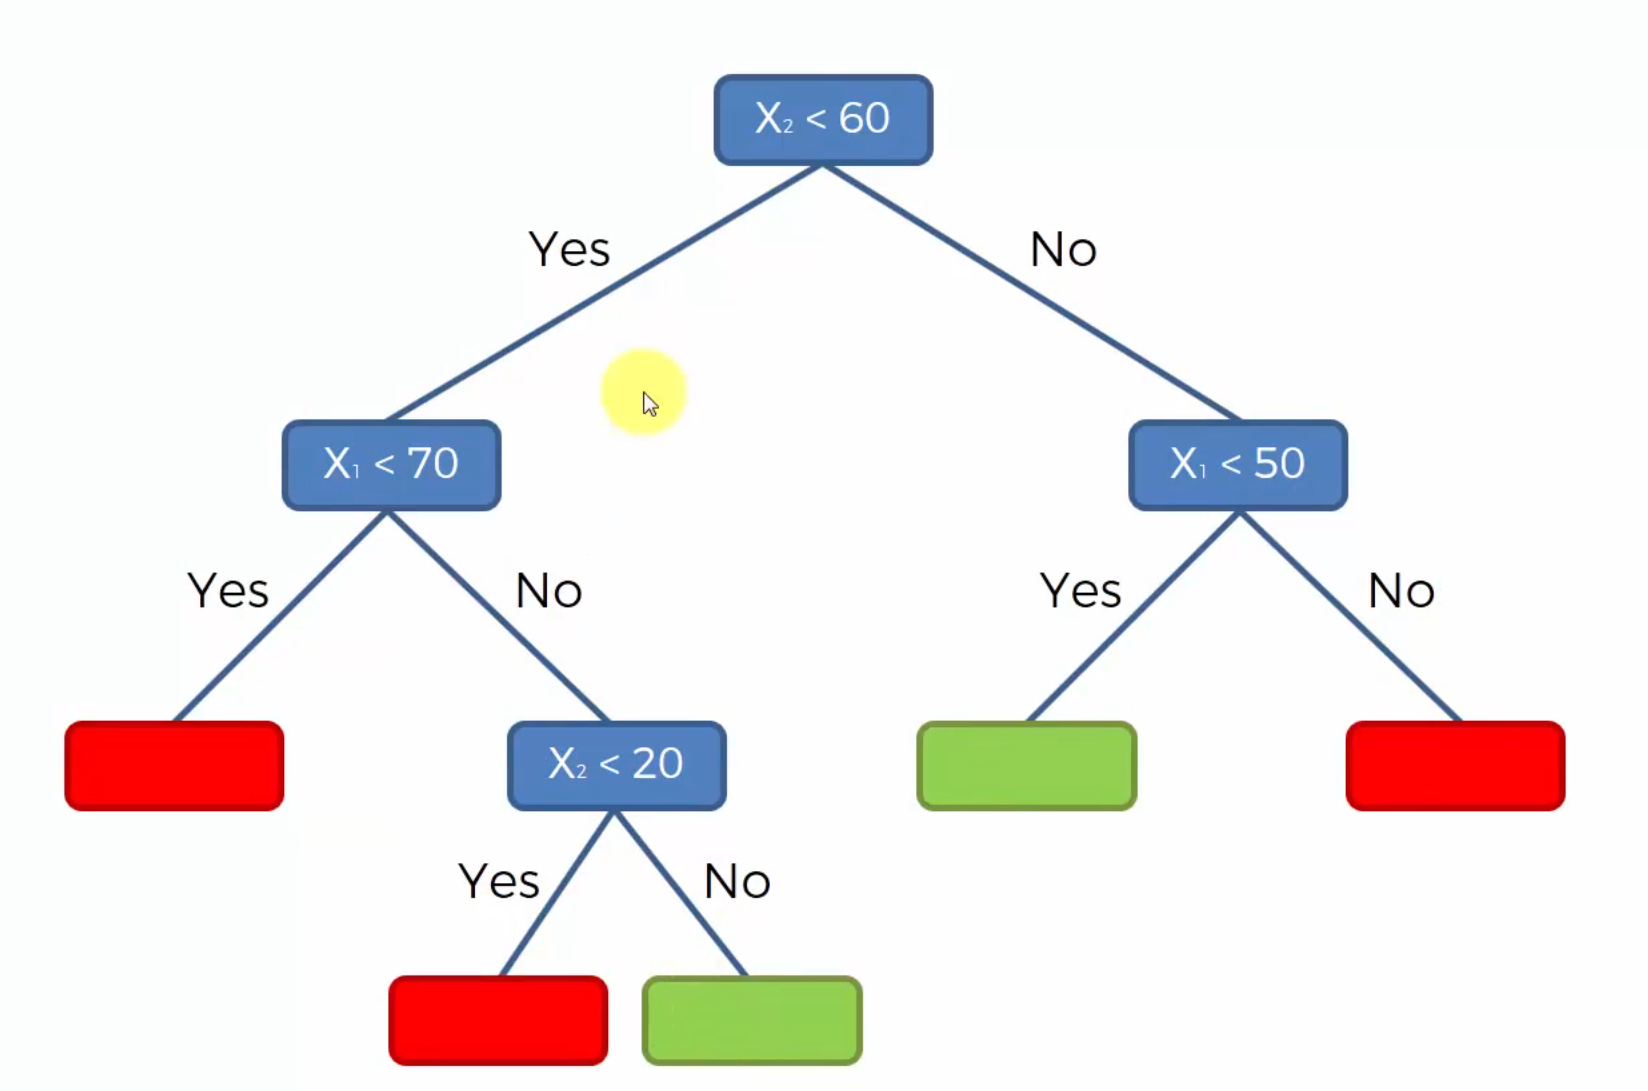

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTclassifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
DTclassifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

## Predicting the Test set results

In [ ]:
y_pred = DTclassifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1)[:10])

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]]


## Making the Classification report

[examples here](https://opensourceconnections.com/blog/2016/03/30/search-precision-and-recall-by-example/)

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.91      0.96      0.94        55
           1       0.91      0.80      0.85        25

    accuracy                           0.91        80
   macro avg       0.91      0.88      0.89        80
weighted avg       0.91      0.91      0.91        80



## Visualising the Training set results

/tmp/ipython-input-1094869398.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


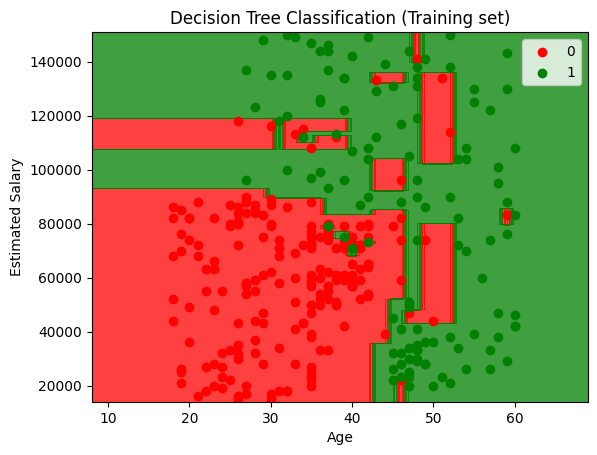

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 100))
plt.contourf(X1, X2, DTclassifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## K-fold cross validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

kf = KFold(shuffle=True, n_splits=5)
scores = cross_val_score(DTclassifier, X, y, cv=kf)

print(scores)
print(np.mean(scores))

[0.775  0.825  0.8375 0.8625 0.8375]
0.8275


# Task for you

Try to build model which is capabale to recognize handwritten digits [0-9]

Use cross validation to evaluate performance

(1797, 64)


<Figure size 640x480 with 0 Axes>

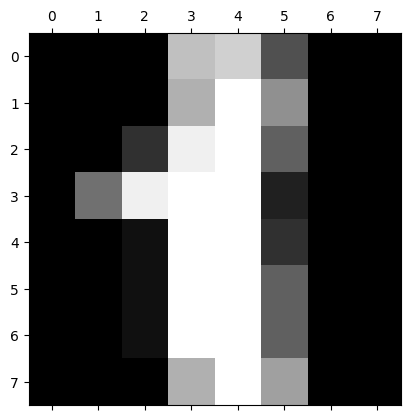

<Figure size 640x480 with 0 Axes>

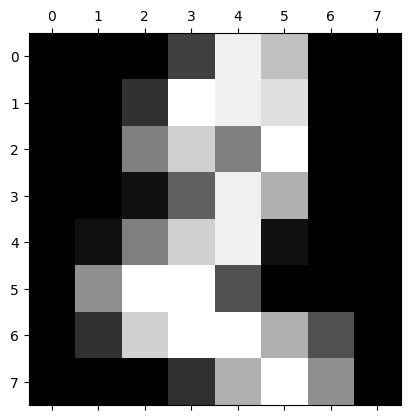

<Figure size 640x480 with 0 Axes>

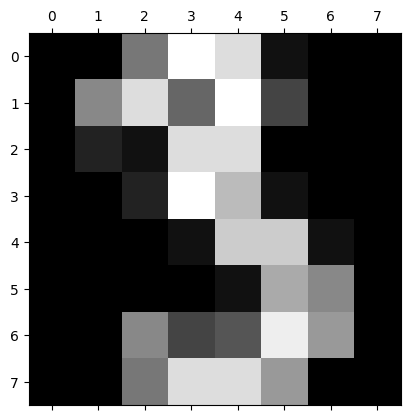

<Figure size 640x480 with 0 Axes>

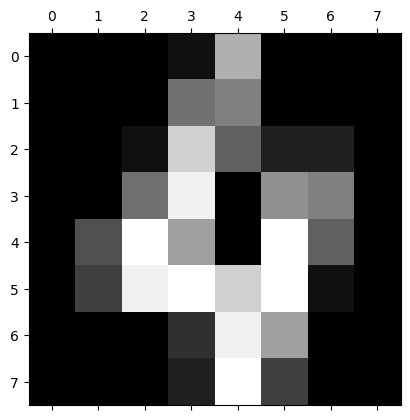

<Figure size 640x480 with 0 Axes>

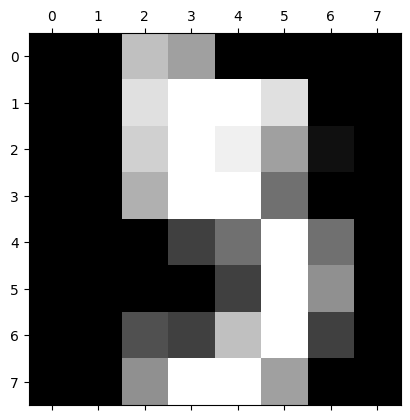

<Figure size 640x480 with 0 Axes>

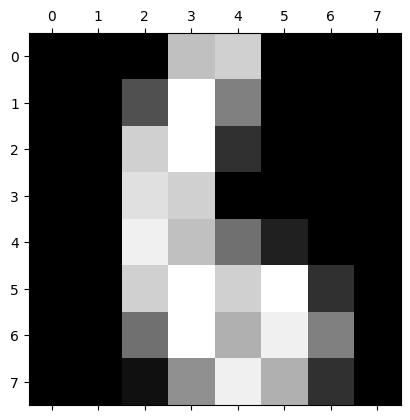

<Figure size 640x480 with 0 Axes>

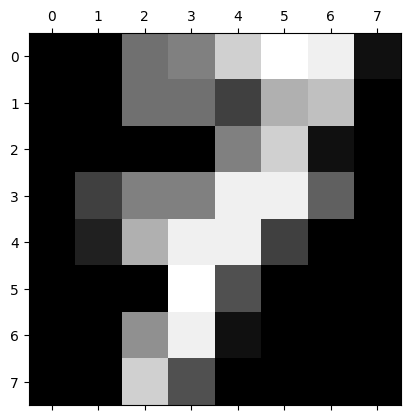

<Figure size 640x480 with 0 Axes>

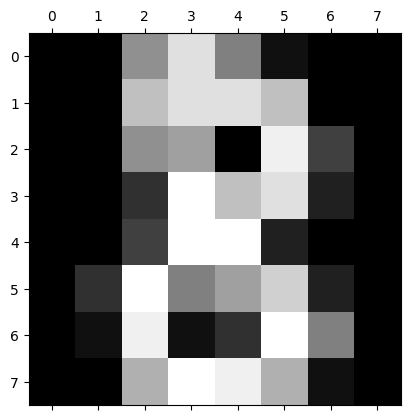

<Figure size 640x480 with 0 Axes>

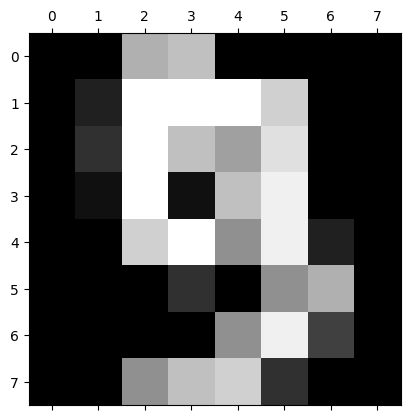

In [ ]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
print(digits.data.shape)

for i in  range(1, 10):
  plt.gray()
  plt.matshow(digits.images[i])
  plt.show()

In [ ]:
y = digits.target
y.shape

(1797,)

In [ ]:
X = digits.data

In [ ]:
X[65]

array([ 0.,  0.,  0.,  9., 10.,  0.,  0.,  0.,  0.,  0.,  7., 16.,  7.,
        0.,  0.,  0.,  0.,  0., 13., 13.,  1.,  0.,  0.,  0.,  0.,  0.,
       15.,  7.,  0.,  0.,  0.,  0.,  0.,  4., 16., 15., 12.,  7.,  0.,
        0.,  0.,  2., 16., 12.,  4., 11., 10.,  0.,  0.,  0.,  8., 14.,
        5.,  9., 14.,  0.,  0.,  0.,  0.,  6., 12., 14.,  9.,  0.])

In [ ]:
y[65]

np.int64(6)

<Figure size 640x480 with 0 Axes>

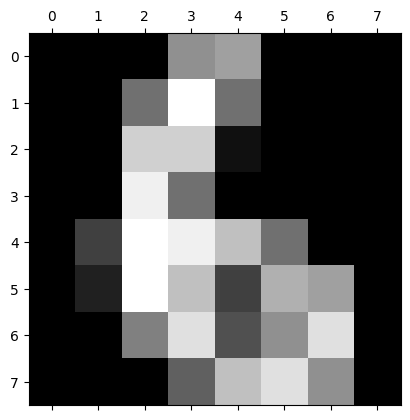

In [ ]:
plt.gray()
plt.matshow(digits.images[65])
plt.show()

In [ ]:
from sklearn.metrics import classification_report